In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, datasets, transforms
import matplotlib.pyplot as plt
import pickle
import urllib.request

import numpy as np
import math
from PIL import Image

%matplotlib inline

In [3]:
def model_instancier(**kwargs):
    """
    Instanciate a ResNet10 model (ResNet18 with only 1 block per layer).

    Parameters
    ----------
    **kwargs: dict
        Keyword arguments to pass to the ResNet18 constructor.

    Returns
    -------
    model: nn.Module
        The instantiated ResNet10 model.
    """
    _model = models.resnet18(**kwargs)
    for i in range(1, 5):
        setattr(_model, f"layer{i}", getattr(_model, f"layer{i}")[0])
    return _model

classes = [0, 1]

In [4]:
from last_layer import LastLayer

classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier()
setattr(model, classifier_name, LastLayer())

model.load_state_dict(
    torch.load("final_model.pth", weights_only=True, map_location=device)
)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): BasicBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel

In [5]:
val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)

## Part 1: Grad-CAM implementation

In [6]:

class Hook:
    """
    Forward and backward hook for a target nn.Module to capture feature maps and gradients.
    
    Attributes:
        features (torch.Tensor): Activations from the forward pass.
        grad (torch.Tensor): Gradients w.r.t. the activations.
    """

    def __init__(self, target: nn.Module):
        self.forward_handle = target.register_forward_hook(self.forward)
        self.backward_handle = None
        self.features: torch.Tensor = None
        self.grad: torch.Tensor = None

    def forward(self, module, input, output: torch.Tensor):
        """
        Forward hook to store the output features and attach a gradient hook.
        """
        self.features = output
        self.backward_handle = output.register_hook(self.backward)

    def backward(self, grad: torch.Tensor):
        """
        Backward hook to store the gradient of the output.
        """

        self.grad = grad.clone()[0] # clone seems to be required for densenet121

    def remove(self):
        """
        Remove the registered hooks.
        """
        self.forward_handle.remove()
        if self.backward_handle is not None:
            self.backward_handle.remove()


def get_heat_map(logits: torch.Tensor, hook: Hook, idx: torch.Tensor) -> torch.Tensor:
    """
    Compute the Grad-CAM heat map for a single class index.

    Args:
        logits (torch.Tensor): Output logits from the model.
        hook (Hook): Hook object containing features and gradients.
        idx (torch.Tensor): Index of the target class.

    Returns:
        torch.Tensor: The class-discriminative heat map (ReLU applied).
    """
    logit = logits[0, idx]
    logit.backward(retain_graph=True)
    alphas = hook.grad.mean(dim=(-2, -1), keepdim=True)
    heat_map = torch.sum(alphas * hook.features, dim=1, keepdim=True)
    return F.relu(heat_map)


def match_size(target: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """
    Upsample tensor x to match the spatial size of target.

    Args:
        target (torch.Tensor): Reference tensor whose size to match.
        x (torch.Tensor): Tensor to resize.

    Returns:
        torch.Tensor: Resized tensor.
    """
    size = target.shape[-2:]
    return F.interpolate(x, size=size, mode='bilinear')

def grad_cam(model: nn.Module, layer: nn.Module, input_image: torch.Tensor, topk: int) -> list:
    """
    Compute Grad-CAM heat maps for the top-k classes.

    Args:
        model (nn.Module): The neural network model.
        layer (nn.Module): The target convolutional layer to hook.
        input_image (torch.Tensor): Input image tensor (1, C, H, W).
        topk (int): Number of top classes to compute Grad-CAM for.

    Returns:
        List[Tuple[torch.Tensor, torch.Tensor, str]]: List of tuples (heat_map, probability, class_name)
    """
    model.zero_grad(set_to_none=True)
    hook = Hook(layer)
    logits = model(input_image)
    probs = F.softmax(logits, dim=1)

    heat_maps = []

    for idx in torch.argsort(logits, dim=1)[0][-topk:]:
        heat_map = get_heat_map(logits, hook, idx)
        heat_map = match_size(input_image, heat_map)
        prob = probs[0, idx]
        cat = classes[idx.cpu().detach().item()]
        heat_maps.append((heat_map, prob, cat))

    heat_maps.reverse()
    hook.remove()
    return heat_maps

In [13]:
def show_grad_cam(image: torch.Tensor, model: nn.Module, layer: nn.Module, topk: int) -> None:

    heat_maps = grad_cam(model, layer, image, topk)

    n = len(heat_maps) + 1

    cols = min(4, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    img = image[0].permute(1, 2, 0)

    axes[0].imshow(img)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    for ax, (heat_map, prob, cat) in zip(axes[1:], heat_maps):
        ax.imshow(img)
        ax.imshow(
            heat_map[0, 0, ...].detach().cpu(),
            alpha=0.5,
            cmap="jet"
        )
        ax.set_title(f"{cat} : {prob:.2f}")
        ax.axis("off")

    for ax in axes[len(heat_maps) + 1:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
for i, (image, label) in val_dataset:
    pred = model(input_image.unsqueeze(0))

In [14]:
layer = model.layer4
topk = 2

1


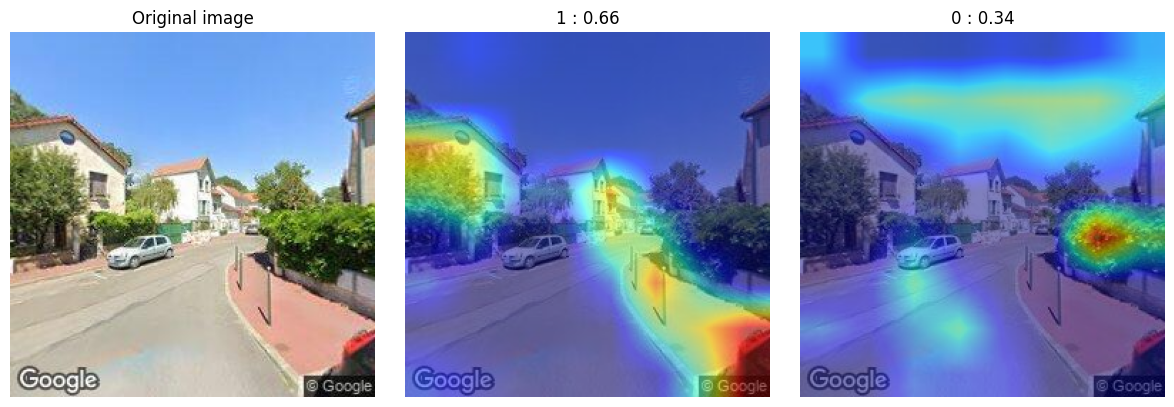

In [ ]:
i = 26

input_image, label = val_dataset[i]
print(label)
show_grad_cam(input_image.unsqueeze(0), model, layer, topk)